RAG approach - Introduction 

1 What is a RAG, and why use one? 

1.1 The problem: classifying free-text labels Statistical agencies routinely receive free-text descriptions of economic activities — from business registration forms, surveys, or administrative records — that need to be assigned a code from a standardised nomenclature such as NACE 2.1. This nomenclature contains hundreds of codes, each associated with a precise definition and scope notes.

Doing this manually is expensive. Automating it with a language model is appealing, but a naive approach — asking the model “what is the NACE code for this activity?” — has a major weakness: LLMs do not reliably memorise fine-grained nomenclatures. They may confuse similar codes, invent non-existent ones, or produce codes that belong to an older version of the classification.

1.2 A solution: Retrieval-Augmented Generation

RAG (Retrieval-Augmented Generation) addresses this by splitting the task into two stages:

- Retrieve — find the NACE codes whose descriptions are semantically closest to the input label, using a vector database and a dedicated language model.
- Generate — ask an LLM to pick the best code from the retrieved shortlist, not from memory.

This approach combines the semantic power of embedding models with the reasoning ability of generative models, while keeping the LLM anchored to a controlled list of valid options.

RAG workflow: Part 1 builds the vector index from NACE definitions; Part 2 runs the inference pipeline on new activity labels.

A vector database is a storage system designed to hold high-dimensional numerical vectors (embeddings) and retrieve them by similarity rather than by exact match.

When a text is processed by an embedding model, it is converted into a dense vector of hundreds or thousands of numbers that encode its meaning. A vector database indexes these vectors so that, given a query vector, it can efficiently return the k nearest neighbours — the stored vectors that are most semantically similar to the query.

Key properties:

- Semantic search: finds documents by meaning, not keywords.
- Fast approximate search: uses algorithms such as HNSW (Hierarchical Navigable Small World) to search millions of vectors in milliseconds.
- Payload storage: each vector can carry arbitrary metadata (e.g. the NACE code and its description), returned alongside the search result.

In this tutorial we use Qdrant, an open-source vector database, to store and query the embeddings of all NACE 2.1 code descriptions.

1.3 RAG or training a usual ML classifier?
Training a usual ML classifier (like a torchTextClassifiers model) is a legitimate alternative that can yield excellent results when a large annotated dataset is available and the nomenclature is stable. But this approach has two big limitations: retraining is required each time the nomenclature changes, and building a quality training set takes real annotation effort and is not always possible.

With RAG, the knowledge lives in the vector database rather than in the model weights. Updating the nomenclature means re-indexing the changed entries, meaning that no retraining is needed. This makes it a natural fit for statistical nomenclatures, which do evolve over time (NACE 2.1 being a recent example). That said, RAG is not annotation-free either: a labelled evaluation set is still needed to measure pipeline performance and tune its components. The right choice between the two approaches depends on data availability, update frequency, and available compute.

2 What will you learn in this tutorial?
A Retrieval-Augmented Generation (RAG) pipeline combines a fast semantic search layer (vector database + embeddings) with a generation model (LLM). It is designed to:

reduce hallucinations by grounding output in retrieved facts
provide up-to-date domain knowledge without retraining the LLM
scale to large knowledge bases by retrieving only the most relevant items per query
In this tutorial, the “retrieval” stage is handled by Qdrant and the “generation” stage by the SSPCloud llm.lab OpenAI-compatible API (see the doc here). https://www.sspcloud.fr/document?path=SSPCloud%E2%90%A3Documentation%E2%80%BAOn%E2%90%A3Demand%E2%90%A3LLM%E2%80%BAIntroduction
The tutorial is divided into two notebooks that map directly to the two parts of the workflow above.

In this introduction, there may be many technical terms you do not understand, and you may feel a bit lost. This is completely normal. The next part of the project with explain many things, and do not hesitate to ask explanations to Claude, ChatGPT or any IA tool.

2.1 How RAG works (step-by-step)
1. Query input — User submits a natural language question, e.g. “industrial bakery”
2. Query embedding — Use an embedding model (qwen3-embedding-8b) to encode the query into a vector of size 4096.
3. Vector search — Query the Qdrant collection using the query vector to retrieve nearest neighbours (top-N contextual docs). Qdrant computes a distance/similarity score between the query vector and each stored vector. Common metrics include:
- cosine similarity (most common, compares angle between vectors; 1 = identical)
- dot product (fast, works well with normalised embeddings)
- Euclidean/L2 distance (straight-line distance in vector space)
In the notebook, you can configure distance='Cosine' when creating the collection.
4. Prompt assembly — use your retrieved vectors (points), and use their metadata (payloads) to compile a context-augmented prompt.
5. Prompt construction — Build a final prompt containing: a system instruction (task definition), the retrieved context, and the user query.
6. LLM generation — Send the prompt to a generation model via client_llmlab.chat.completions.create(...).
7. Post-processing — Parse the output and optionally apply business rules (e.g. label mapping, thresholding).
8. Evaluation — Compare against ground truth labels and measure metrics (accuracy, F1, precision/recall).

2.1.1 Simple pseudocode

query_text = "industrial bakery"
query_vector = llm_lab.embeddings.create(
    model='qwen3-embedding-8b', input=query_text
).data[0].embedding

hits = qdrant_client.search(
    collection_name='nace_vdb', query_vector=query_vector, limit=5
)
context = "\n".join([hit.payload['text'] for hit in hits])

prompt = f"Use the following context to answer the question:\n{context}\nQuestion: {query_text}\nAnswer:"
result = llm_lab.chat.completions.create(
    model='gpt-oss:20b',
    messages=[{'role': 'user', 'content': prompt}]
)
print(result.choices[0].message.content)

Tutorial 1 — Building the vector database (2-rag-vdb.qmd)

- Preprocess and embed all NACE 2.1 code descriptions using a dedicated language model
- Store the resulting vectors in a Qdrant collection
- Understand what a vector database is and how nearest-neighbour search works

Tutorial 2 — Running and evaluating the RAG pipeline (2-rag-generation.qmd)

- Load and inspect annotated examples
- Embed a free-text activity label and retrieve the k closest NACE candidates
- Build a retrieval + generation function that queries Qdrant and sends retrieved context to an LLM
- Compare predicted labels with ground truth for evaluation
- Understand how retrieval quality affects final generation quality

Note:
Both notebooks share the same infrastructure (Qdrant + llm.lab) and the same global parameters. Tutorial 1 must be completed before Tutorial 2, as it creates the vector collection that the pipeline depends on.

3 Technical requirements
3.1 Services
You will need access to two services hosted on the SSPCloud:

Service:	Role
Qdrant:	Vector database storing NACE embeddings
llm.lab:	LLM provider on premise (embedding model + generative model)

3.2 Credentials
Create a .env file at the root of your repository with the following variables:

QDRANT_URL=https://YOURNAMESPACE-qdrant.user.lab.sspcloud.fr/
QDRANT_API_KEY=xxxxxxxxxxxxxxxxxxxx
QDRANT_API_PORT=443
LLMLAB_API_KEY=xxxxxxxxxxxxxxxxxxxx
LLMLAB_URL=https://llm.lab.sspcloud.fr/api

Never commit your .env file. Add it to your .gitignore immediately. Leaking API keys can expose your services to unauthorised use.

3.2.1 Getting your llm.lab API key
Go to the llm.lab interface and sign in with your SSPCloud account.
Open Settings (top right) → Account → API Keys.
Generate a new key and copy it into LLMLAB_API_KEY.

Copy the generated token and save it as QDRANT_API_KEY. The URL follows the pattern https://YOURNAMESPACE-qdrant.user.lab.sspcloud.fr/.

You can also access your Qdrant Api key when you click on “Open” the Qdrant service. The password shown in the pop-up bubble is your API key.

3.3 Loading credentials in Python
Once your .env file is ready, load the variables at the start of each notebook:

In [29]:
from dotenv import load_dotenv
load_dotenv()

True

To verify that a variable was loaded correctly:

In [30]:
import os
try:
    QDRANT_URL = os.environ["QDRANT_URL"]
    print("QDRANT_URL loaded successfully")
except KeyError:
    raise ValueError("QDRANT_URL is not set — check your .env file")

QDRANT_URL loaded successfully


If load_dotenv() doesn’t work but every thing seems fine, don’t forget to make sure that Python runs in the right working directory with os.getcwd()and os.chdir("funathon-project2).

RAG pipeline approach - Create a vector database

Forewords

This first part will show you how to build a vector database, i.e., the “augmented” knowledge aimed to guide your LLM’s responses.

The simplified workflow will be as follows:

0. Create a proper working environment with all needed connections (s3: object storage, qdrant: vector database and llm.lab: LLM provider)
1. Take the NACE2.1 code definitions (code + title, + inclusions + exclusions in plain text)
2. Concatenate these pieces of information for each unique NACE (one code => 1 text)
3. Embed all these texts (1 text => 1 vector point)
4. Upload the points to Qdrant (the vector database service)

Prepare your environment

Exercise 1: Connections

Question 0
Load your secrets stored in the .env file into your environment.

In [31]:
import os
from dotenv import load_dotenv

load_dotenv()

True

If load_dotenv() doesn’t work but every thing seems fine, don’t forget to make sure that Python runs in the right working directory with os.getcwd()and os.chdir("funathon-project2).

Question 1
Create your llm.lab connection using openai client. Please name this client client_llmlab.
You will need to use your creds os.environ["LLMLAB_URL"] and os.environ["LLMLAB_API_KEY"] (see the previous chapter).

More information here about OpenAI API. https://github.com/openai/openai-python

(Go to next question to see the answer).

Question 2
Print all the available models (kindly made available to everyone by the SSPcloud team ❤️)
You can notice the llm.lab platform provides both generation and embedding models.

The OpenAI API provides a standard way to interact with language models for text generation and embeddings. Here, instead of OpenAI’s cloud, we connect to a remote OpenWebUI/vLLM server (the famous llm.lab from the even more famous SSPCloud), which hosts the models. The API interface stays the same, so you can generate text or create embeddings with calls like .completions.create() or .embeddings.create() while all computation happens on the OpenWebUI/vLLM server.

In [ ]:
pip install openai

In [38]:
from openai import OpenAI

client_llmlab = OpenAI(
    base_url=os.environ["LLMLAB_URL"],
    api_key=os.environ["LLMLAB_API_KEY"],
)

# Print models list
models = client_llmlab.models.list()
for model in models.data:
    print(f"ID: {model.id}")

ID: gemma4-26b-moe
ID: qwen3-6-35b-moe
ID: qwen3-embedding-8b


Question 3
Create a connection to your Qdrant server. Please name it client_qdrant.
Check all your existing collections (= databases). Probably not a single one for now.
Find the documentation here to dive deeper 😉. https://python-client.qdrant.tech/

In [ ]:
pip install qdrant_client

In [40]:
from qdrant_client import QdrantClient

client_qdrant = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
    port=os.environ["QDRANT_API_PORT"],
    check_compatibility=False
)

collections = client_qdrant.get_collections()
for collection in collections.collections:
    print(collection.name)

nace-collection


Get and process NACE data

Time to import our data: the official NACE2.1 definitions!

The data are stored in the s3 storage system of the SSPCloud platform (uploaded from Eurostat)

Exercise 2: handling NACE data

Question 1
Import NACE data (for example, as a list of dictionaries with the structure below)

In [41]:
import duckdb
con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

path_nace = 'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/NACE_Rev2.1_Structure_Explanatory_Notes_EN.tsv'
query_definition = f"SELECT * FROM read_csv('{path_nace}')"
table = con.execute(query_definition).to_arrow_table()
nace = table.to_pylist()

nace[25]

{'ORDER_KEY': 260,
 'ID': '0143',
 'CODE': '01.43',
 'HEADING': 'Raising of horses and other equines',
 'PARENT_ID': '014',
 'PARENT_CODE': '01.4',
 'LEVEL': 4,
 'Implementation_rule': None,
 'Includes': 'This class includes:\\n- raising and breeding of horses, asses, mules or hinnies, regardless of the purpose',
 'IncludesAlso': None,
 'Excludes': 'This class excludes:\\n- operation of racing and riding stables (if they do not have breeding activities), see 93.19'}

Question 2
Build a class NaceDocument that will help you handle your NACE documents :

Cleans features (‘HEADING’, ‘Includes’, etc.) with a _clean method;
Checks your data (example: hierarchical coherence);
Creates a structured text for each code:
- example: attribute text, created by a to_embedding_text method;
- this text will be ready to be embedded;
- It would be best to parametrize whether to include or not each possible field (e.g : text with or without “Excludes” feature).

Not familiar with @dataclass or @classmethod? See Python refresher. https://aiml4os.github.io/funathon-project2/2-rag-vdb#tip-python-refresher

Create all NaceDocument instances from nace list.

In [13]:
from dataclasses import dataclass, field
from typing import Optional

def _clean(value) -> Optional[str]:
    """Normalize to stripped single-line string, or None if empty/missing."""
    if value is None:
        return None
    # str() handles non-string values (int, float...) from raw dicts
    # replace("\n", " ") flattens multiline strings to a single line
    # split() tokenizes on any whitespace, join(" ") rebuilds with single spaces
    cleaned = " ".join(str(value).replace("\n", " ").split())
    # Empty string is falsy in Python — return None instead for consistency
    return cleaned or None

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)

    @classmethod
    def from_raw(cls, raw: dict, with_includes_also=True, with_excludes=False,) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

nace_documents = []
for nace_code in nace:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

Question 3
Create a text from a single Nace code example, with or without Excludes field

In [15]:
from pprint import pprint

i = 50
print(f"Printing index {i}:")

print("=============================================")
print("=============================================")

nace_example = nace[i]
doc_example = NaceDocument.from_raw(nace_example)

print("\nPrinting text to embed (WITH exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=True,
)
print(doc_example.text)

print("=============================================")
print("=============================================")

print("\nPrinting text to embed (WITHOUT exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=False,
)
print(doc_example.text)

Printing index 50:

Printing text to embed (WITH exclusions):
# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)

Printing text to embed (WITHOUT exclusions):
# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)


Embed your NACE text descriptions

Now let’s choose an embedding model. We will use qwen3-embedding-8b, available on HuggingFace (like all other models provided by llm.lab).

For later use, we need to know the dimension of the vectors output by our model: 4096 (see the model card on HuggingFace). https://huggingface.co/Qwen/Qwen3-Embedding-8B

In [16]:
EMB_MODEL_NAME = "qwen3-embedding-8b"
emb_dim = 4096

Exercise 3: create a Qdrant vector store and feed it with embedded NACE text descriptions

Question 1
Use your client_qdrant and the method create_collection to create a new Qdrant collection (e.g: a new vector database). For example, call it nace-collection.

In [17]:
from qdrant_client.models import Distance, VectorParams

COLLECTION_NAME = "nace-collection"

# Delete the collection if necessary
if client_qdrant.collection_exists(collection_name=COLLECTION_NAME):
    client_qdrant.delete_collection(collection_name=COLLECTION_NAME)

# Create the collection
client_qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=emb_dim,
        distance=Distance.COSINE
    )
)

True

So far, you should see your new empty collection from Qdrant’s UI

Question 2

It’s now time to embed your NACE descriptions (the text attribute of each NaceDocument built earlier) using your client_llmlab connection.

a) Enrich your NaceDocument class:

- Add a new attribute vector (initialized to None, not set by the constructor) that will hold the embedding vector.
- Add a get_embeddings method that calls the embedding model via client_llmlab and stores the result in self.vector.

b) Run the method on a couple of documents only (no need to fire 1,047 requests at this stage).

c) Inspect the embedding vectors: what is their dimension? what do the values look like?

Hint: structure of the call to client_llmlab.embeddings.create
The OpenAI-compatible API exposes embeddings through client.embeddings.create(...). In pseudo-code, the call looks like this:

response = client_llmlab.embeddings.create(
    model = <name of an embedding model from Exercise 1>,
    input = <the text you want to embed>,
)

The returned response object follows the OpenAI schema — the embedding vector itself lives inside response.data[...]. Browse the object (or check the OpenAI docs) to find where exactly. https://platform.openai.com/docs/api-reference/embeddings/create

💡 Tips:

- Wrap the call in a try / except block so a failed request doesn’t silently corrupt your data.
- input accepts either a single string or a list of strings — pick whichever fits your method best.
- To avoid verbose output when creating embeddings, you can add a verbose option .

In [18]:
from dataclasses import dataclass, field
from typing import Optional, List


@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)
    vector: Optional[List[float]] = field(default=None, init=False)

    @classmethod
    def from_raw(
        cls,
        raw: dict,
        with_includes_also=True,
        with_excludes=False,
    ) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

    def get_embeddings(
        self,
        client_llmlab,
        emb_model: str,
        verbose = False,
    ) -> List[float]:
        try:
            response = client_llmlab.embeddings.create(
                model=EMB_MODEL_NAME,
                input=self.text
            )

            self.vector = response.data[0].embedding
            if verbose:
                return self.vector

        except Exception as e:
            raise RuntimeError(f"Embedding failed for doc {self.code}: {str(e)}")

In [21]:
# Recreate your NACE documents (that class has been updated)

sample_size = 50

nace_documents = []
for nace_code in nace[:sample_size]:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

for nace_doc in nace_documents:
    nace_doc.get_embeddings(
        client_llmlab,
        EMB_MODEL_NAME,
    )

Question 3

Inspect your embeddings

In [22]:
print("\nPrinting the first document:")
print(nace_documents[0])

print("\nPrinting the embedding vector of the first document:")
print(nace_documents[0].vector)

print(f"\nLength of this vector: {len(nace_documents[0].vector)}")


Printing the first document:
NaceDocument(code='A', heading='AGRICULTURE, FORESTRY AND FISHING', level=1, parent_code=None, includes='This section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and the production of animal products from a farm or natural habitats.', includes_also='This section also includes organic agriculture, aquaculture, the growing of genetically modified crops and the raising of genetically modified animals.', excludes='This section excludes undifferentiated subsistence goods-producing activities of households, which are classified in class 98.10.', text='# Code: A\n# Title: AGRICULTURE, FORESTRY AND FISHING\n\n## Includes:\nThis section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and th

Question 4

Update once again your NaceDocument to create a new method to build a Qdrant PointStruct like dictionary (see the PointStruct note). https://aiml4os.github.io/funathon-project2/2-rag-vdb#pointstruct
This structure is required by the Qdrant API.

In [23]:
from dataclasses import dataclass, field
from typing import Optional, List
from uuid import uuid5, NAMESPACE_DNS
from qdrant_client.models import PointStruct

NACE_NAMESPACE = uuid5(NAMESPACE_DNS, "nace-rev2")

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)
    vector: Optional[List[float]] = field(default=None, init=False)

    @classmethod
    def from_raw(
        cls,
        raw: dict,
        with_includes_also=True,
        with_excludes=False,
    ) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

    def get_embeddings(
        self,
        client_llmlab,
        emb_model: str,
        verbose = False,
    ) -> List[float]:
        try:
            response = client_llmlab.embeddings.create(
                model=EMB_MODEL_NAME,
                input=self.text
            )

            self.vector = response.data[0].embedding
            if verbose:
                return self.vector

        except Exception as e:
            raise RuntimeError(f"Embedding failed for doc {self.code}: {str(e)}")

    def to_qdrant_point(
        self,
    ) -> PointStruct:

        if not hasattr(self, "vector") or self.vector is None:
            raise ValueError("vector is missing or Null")
        return PointStruct(
            # uuid5 is deterministic: same namespace + code always yields the same UUID
            # stable across runs, valid for Qdrant, no hacky string manipulation needed
            id=str(uuid5(NACE_NAMESPACE, self.code)),
            vector=self.vector,
            payload={
                "code": self.code,
                "level": self.level,
                "parent_code": self.parent_code,
                # Storing the text used for embedding enables inspection and debugging
                "text": self.text,
            }
        )

Question 5

Recreate your Nace documents, all your embeddings and generate all points (PointStruct). Please take a look at this callout to get a sense of the limits of this approach with a view to production use. https://aiml4os.github.io/funathon-project2/2-rag-vdb#prodgrad

In [24]:
nace_points = []

for nace_code in nace:
    nace_doc = NaceDocument.from_raw(
        raw=nace_code,
        with_includes_also=True,
        with_excludes=True
    )

    nace_doc.get_embeddings(
        client_llmlab,
        EMB_MODEL_NAME,
    )

    nace_points.append(
        nace_doc.to_qdrant_point()
    )

In [43]:
import json

point = nace_points[0]
point_dict = point.model_dump()

# Truncate the vector for readability (full vector is hundreds of floats)
vector = point_dict["vector"]
point_dict["vector"] = f"[{vector[0]:.4f}, {vector[1]:.4f}, ..., {vector[-1]:.4f}]  ({len(vector)} dims)"

print("Check the first PointStruct:\n")
print(json.dumps(point_dict, indent=2, ensure_ascii=False))

Check the first PointStruct:

{
  "id": "bf20fdf8-5b6a-5d28-b1f6-7a472c5564ac",
  "vector": "[0.0139, 0.0089, ..., -0.0044]  (4096 dims)",
  "payload": {
    "code": "A",
    "level": 1,
    "parent_code": null,
    "text": "# Code: A\n# Title: AGRICULTURE, FORESTRY AND FISHING\n\n## Includes:\nThis section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and the production of animal products from a farm or natural habitats.\n\n## Also includes:\nThis section also includes organic agriculture, aquaculture, the growing of genetically modified crops and the raising of genetically modified animals.\n\n## Excludes:\nThis section excludes undifferentiated subsistence goods-producing activities of households, which are classified in class 98.10."
  }
}


Question 6

Upload your points into your Qdrant collection, using the client_qdrant.upsert method. Try to batch the upload (instead of sending all 1,047 points in a single request).

In [ ]:
pip install more_itertools

In [ ]:
pip install tqdm

In [47]:
from more_itertools import chunked
from tqdm import tqdm

BATCH_SIZE = 16
batches = list(chunked(nace_points, BATCH_SIZE))

for batch in tqdm(batches, desc="Uploading to Qdrant", unit="batch"):
    try:
        client_qdrant.upsert(
            collection_name=COLLECTION_NAME,
            points=batch,
        )
    except Exception as e:
        tqdm.write(f"✗ Batch failed: {e}")

Uploading to Qdrant: 100%|██████████| 66/66 [00:06<00:00,  9.88batch/s]


Question 7

Inspect your Qdrant collection. It should contain 1,047 vectors.

In [48]:
count = client_qdrant.count(collection_name=COLLECTION_NAME)
print(count)

count=1047


Next step

The vector database is ready. In the next notebook you will build the generation side of the RAG pipeline: given a free-text activity description, retrieve the most similar NACE codes from Qdrant and prompt an LLM to pick the right one.

RAG pipeline approach - Query a LLM for automatic coding

Forewords

This second RAG tutorial builds on the vector database created in part 1. It completes the RAG pipeline by loading labelled data, retrieving context from Qdrant, and generating final answers from a query. You will learn how to automatically classify free-text activity labels into the NACE 2.1 nomenclature, and then evaluate the quality of the pipeline at each stage.

RAG pipeline overview

The automated coding workflow is broken down into five steps:

Raw text label
      │
      ▼
 [1] Embedding       ← transform the label into a dense vector
      │
      ▼
 [2] Retrieval       ← find the k nearest neighbours in Qdrant
      │
      ▼
 [3] Augmentation    ← inject retrieved candidates into a structured prompt
      │
      ▼
 [4] Generation      ← LLM inference with a JSON-constrained output
      │
      ▼
 [5] Evaluation      ← compare predictions against reference codes

The RAG acronym specifically refers to the combination of steps 2 (Retrieval) and 4 (Generation): instead of asking the LLM to code from memory — which would be unreliable for fine-grained nomenclatures — we supply it with the most semantically relevant candidates from the vector store.

Why do we need the generation step?

Retrieval gives us the top-k most semantically similar NACE descriptions for a given activity label — but it doesn’t pick the right code. For our use case, the generation step is what turns a list of candidates into a single classification decision:

- Disambiguation among close candidates: the top-5 retrieved codes often look very similar (e.g. several variants of “retail trade”). The LLM compares them against the full activity label and chooses the most specific one.
- Handling imprecise or messy inputs: real activity labels are often short, abbreviated or ambiguous. The LLM can interpret them by leveraging the retrieved definitions as context.
- Structured output: by constraining the LLM to return a JSON with the chosen NACE code, we get a directly usable prediction — not free-form prose.

Connections and global parameters

In [50]:
# Models
EMB_MODEL_NAME = "qwen3-embedding-8b"   # Embedding model
GEN_MODEL_NAME = "gemma4-26b-moe"          # Generative model

# Qdrant
COLLECTION_NAME = "nace-collection"
RETRIEVER_LIMIT = 5    # Number of candidates returned by the vector search

# Generation
TEMPERATURE = 0.1      # Low temperature → more deterministic, reproducible outputs

# Evaluation
SAMPLE_SIZE = 500       # Number of activities to evaluate (increase for more robust results)

Why a low temperature? Temperature controls the degree of randomness in generation. For a closed-list classification task, we want stable and reproducible answers: a value between 0.0 and 0.2 is recommended. Higher values are better suited to creative tasks.

First attempt on a single activity label
Before running the pipeline on the full dataset, test each component step by step.

The following questions will follow the steps described below.

Exercise 1: Test the pipeline on a single example

Question 1 — Embed an activity label

Embedding is the process of transforming a text into a (high-dimensional) numerical vector that captures its semantics. Two semantically similar texts will have vectors that are close to each other in the vector space. This property is what enables nearest-neighbour search.

Use client_llmlab.embeddings.create to embed the activity label below (see the doc), and store the embedding vector into a search_embedding object. https://developers.openai.com/api/reference/python/resources/embeddings/methods/create

In [52]:
activity = "Installation, maintenance and repair of residential air conditioning systems for private customers"

In [53]:
response = client_llmlab.embeddings.create(
    model=EMB_MODEL_NAME,
    input=activity
)

search_embedding = response.data[0].embedding

print(f"Vector created of length: {len(search_embedding)}")

Vector created of length: 4096


Note: Vector dimension: the vector size depends on the embedding model and is fixed at collection creation time (tutorial 1). You must use the same embedding model at every stage of the pipeline.

Question 2 — Retrieval: search for NACE candidates

Retrieval consists of querying the Qdrant vector store to find the k NACE codes whose descriptions are semantically closest to the label being coded.

Use client_qdrant.query_points with limit=RETRIEVER_LIMIT to get the k closest candidates, then extract from the response two lists:

- codes_retrieved — the NACE codes of the retrieved candidates
- descriptions_retrieved — their associated textual descriptions
These two lists will be reused in the next question to build the prompt sent to the LLM.

In [64]:
points = client_qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=search_embedding,
    limit=RETRIEVER_LIMIT,
)

descriptions_retrieved = []
codes_retrieved = []

for point in points.model_dump()["points"]:
    descriptions_retrieved.append(point["payload"]["text"])
    codes_retrieved.append(point["payload"]["code"])

print(
    f"✓ Vector search completed: {len(descriptions_retrieved)} codes and descriptions retrieved\n"
)
print("Check the first code retrieved ==============\n")
print(descriptions_retrieved[0])

✓ Vector search completed: 5 codes and descriptions retrieved

Check the first code retrieved ==============

# Code: 35.3
# Title: Steam and air conditioning supply


Note: Retriever accuracy: the retrieval step is critical. If the correct code is not among the k returned candidates, the LLM cannot select it. You will compute this metric in Part 3.

Prompt construction

The quality of the prompt directly affects the LLM’s output. A RAG prompt typically has two parts:

- The system prompt: defines the model’s general role and behaviour.
- The user prompt: contains request-specific information (label to code, candidates, output format instructions).

Constraining the output to JSON format is a best practice: it simplifies automatic parsing and reduces format hallucinations.

The vast majority of LLMs now support Structured Outputs, allowing you to enforce a strict JSON schema on the model’s response. Three mechanisms exist, in increasing order of strictness:

- response_format={"type": "json_object"}: the model is constrained to emit valid JSON, but the exact keys are guided by the prompt rather than a formal schema. Simple and widely supported.
- response_format={"type": "json_schema", "json_schema": ...}: the model is constrained to match a precise JSON schema validated at decode time. Stronger guarantee, but requires an explicit schema definition.
- Pydantic + ..chat.completions.parse() (used here): the OpenAI SDK accepts a Pydantic model as response_format and deserialises the response directly into a typed Python object. No json.loads is needed, field types and value constraints are enforced by Pydantic at parse time, and IDEs provide full autocompletion on the result.

In [65]:
SYSTEM_PROMPT = """\
You are an expert classifier for the NACE 2.1 nomenclature (Statistical Classification of Economic Activities in the European Community).

Given a company activity description and a short list of candidate NACE codes, your job is to pick the single most appropriate code from the candidates — or to declare the activity not codable if the description is too ambiguous or vague.

Always reply with a valid JSON object matching the requested schema. No explanations, no extra text.
"""

USER_PROMPT_TEMPLATE = """\
## Activity to classify
{activity}

## Candidate NACE codes and their explanatory notes
{proposed_nace_descriptions}

## Rules
- Pick exactly one code from this list: [{proposed_nace_codes}]. Do not invent codes outside the list.
- If several activities are mentioned, only consider the first one.
- If the description is too vague or ambiguous to decide, return `nace_code: null` and `codable: false`.

## Output — valid JSON only
{{
  "nace_code": "<one code from the candidate list, or null>",
  "codable": <true | false>,
  "confidence": <float between 0.0 and 1.0>
}}
"""

Prompt engineering best practices for classification:

- Constrain the candidate list: by injecting the allowed codes directly into the rules (Pick exactly one code from this list: [...]), we prevent the LLM from inventing a code outside the nomenclature.
- Handle uncertainty explicitly: an ambiguous label should return codable: false rather than a random code — without this escape hatch, the LLM is forced to guess.
- Require a confidence score: useful for filtering unreliable predictions in production (e.g. flag low-confidence cases for human review).
- Show a concrete JSON schema in the prompt: giving the model the exact output shape (with placeholders for each field) yields more reliable parsing than describing it in prose.
- Forbid explanations: combined with response_format={"type": "json_object"} at inference time, this minimises the risk of free-text preambles breaking JSON parsing.

Question 3 — LLM inference

Compile the prompt with the retrieved candidates and run inference. The steps are:

1. Format USER_PROMPT_TEMPLATE by injecting activity, descriptions_retrieved and codes_retrieved.
2. Call client_llmlab.beta.chat.completions.parse() with response_format=NaceClassificationResult.
3. Access the typed result via response.choices[0].message.parsed — no json.loads needed.

beta.chat.completions.parse() vs .create(). The .parse() method is a thin wrapper around .create() that accepts a Pydantic model as response_format. Under the hood it serialises the model’s JSON schema and sends it to the API; on the way back it deserialises the response into the model. If the model returns a field that violates a constraint (e.g. confidence outside [0, 1]) Pydantic raises a ValidationError at parse time, making failures explicit rather than silent.

We first need to create the output schema we want, we do this by defining a pydantic class :

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional

class NaceClassificationResult(BaseModel):
    nace_code: Optional[str] = Field(description="Chosen NACE code from the candidate list, or null")
    codable: bool = Field(description="False if the description is too vague or ambiguous to code")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence score between 0 and 1")

In [67]:
import json

user_prompt = USER_PROMPT_TEMPLATE.format(
    activity=activity,
    proposed_nace_descriptions="## " + "\n\n## ".join(descriptions_retrieved),
    proposed_nace_codes=", ".join(codes_retrieved)
)

response = client_llmlab.chat.completions.parse(
    model=GEN_MODEL_NAME,
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt}
    ],
    temperature=TEMPERATURE,
    response_format=NaceClassificationResult,
)

llm_response: NaceClassificationResult = response.choices[0].message.parsed
print(json.dumps(llm_response.model_dump(), indent=2))

{
  "nace_code": "43.2",
  "codable": true,
  "confidence": 0.9
}


Inference on multiple activities

Next, let’s use some synthetic data. We will:

- run automatic classification on a sample of labelled activities,
- build metrics to evaluate the quality of the coding process.

Load the data

In [69]:
import duckdb

con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

query_definition = f"""
SELECT *
FROM read_parquet(
  'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet'
)
USING SAMPLE {SAMPLE_SIZE}
"""

annotations = (
    con.sql(query_definition)
    .to_df()
    .to_dict(orient="records")
)
print(f"Dataset loaded: {len(annotations)} rows")
print(f"Keys: {list(annotations[0].keys())}")
annotations[:5]

Dataset loaded: 500 rows
Keys: ['code', 'name', 'label']


[{'code': '47.64',
  'name': 'Retail sale of games and toys',
  'label': 'Provision of play equipment to consumers'},
 {'code': '70.10',
  'name': 'Activities of head offices',
  'label': 'Strategic business direction'},
 {'code': '73.30',
  'name': 'Public relations and communication activities',
  'label': 'Internal communications campaign management'},
 {'code': '70.20',
  'name': 'Business and other management consultancy activities',
  'label': 'Organizational planning and resource allocation'},
 {'code': '66.30',
  'name': 'Fund management activities',
  'label': 'Contractual investment fund governance'}]

Note: Dataset structure: Each row contains a free-text activity label (activity) and its reference NACE 2.1 code (nace_code). These annotations were generated by an agentic AI system and constitute synthetic data. As such, they are well-suited for testing a RAG pipeline on English-language activity labels, but no claim is made about whether they are representative of real-world annotation data.

Utility function: a full pipeline call

Before looping, we encapsulate steps 1–4 into a reusable function.

In [70]:
def run_rag_pipeline(activity: str) -> dict:
    """
    Run the full RAG pipeline for a single activity label.

    Parameters
    ----------
    activity : str
        Free-text economic activity label to be coded.

    Returns
    -------
    dict with keys:
        - nace_code (str | None) : predicted NACE code
        - codable (bool)        : True if the label could be coded
        - confidence (float)    : confidence score (0–1)
        - retrieved_codes (list): candidates returned by the retriever
    """
    # --- Step 1: Embedding ---
    emb_response = client_llmlab.embeddings.create(model=EMB_MODEL_NAME, input=activity)
    embedding = emb_response.data[0].embedding

    # --- Step 2: Retrieval ---
    points = client_qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=embedding,
        limit=RETRIEVER_LIMIT,
    )
    descriptions_retrieved = []
    codes_retrieved = []
    for point in points.model_dump()["points"]:
        descriptions_retrieved.append(point["payload"]["text"])
        codes_retrieved.append(point["payload"]["code"])

    # --- Step 3: Prompt construction ---
    user_prompt = USER_PROMPT_TEMPLATE.format(
        activity=activity,
        proposed_nace_descriptions="## " + "\n\n## ".join(descriptions_retrieved),
        proposed_nace_codes=", ".join(codes_retrieved),
    )

    # --- Step 4: LLM inference ---
    gen_response = client_llmlab.chat.completions.parse(
        model=GEN_MODEL_NAME,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=TEMPERATURE,
        response_format=NaceClassificationResult,
    )

    result = gen_response.choices[0].message.parsed.model_dump()
    # Keep retrieved candidates for retriever evaluation
    result["retrieved_codes"] = codes_retrieved

    return result

Inference loop

Exercise 2: Code all activities in the dataset

Apply run_rag_pipeline to every row of the annotations list. Store the results in a DataFrame called results.

Note: The default sample size is SAMPLE_SIZE = 100, which keeps inference fast and avoids consuming too many resources. Each call to the pipeline involves two API requests (embedding + generation), so larger samples will take proportionally longer. Feel free to increase SAMPLE_SIZE in the global parameters to get more robust evaluation metrics.

In [71]:
from tqdm import tqdm
import pandas as pd

records = []

for row in tqdm(annotations, total=len(annotations), desc="Coding"):
    activity_label = row["label"]
    true_code      = row["code"]

    try:
        pred = run_rag_pipeline(activity_label)
    except Exception as e:
        pred = {
            "nace_code":       None,
            "codable":        False,
            "confidence":     0.0,
            "retrieved_codes": []
        }
        print(f"⚠ Error for '{activity_label[:60]}...': {e}")

    records.append({
        "activity":        activity_label,
        "true_code":       true_code,
        "pred_code":       pred.get("nace_code"),
        "codable":         pred.get("codable", False),
        "confidence":      pred.get("confidence", 0.0),
        "retrieved_codes": pred.get("retrieved_codes", []),
    })

results = pd.DataFrame(records)
print(f"\n✓ Inference complete: {len(results)} activities processed")
results.head()

Coding: 100%|██████████| 500/500 [10:05<00:00,  1.21s/it]


✓ Inference complete: 500 activities processed


,activity,true_code,pred_code,codable,confidence,retrieved_codes
0,Provision of play equipment to consumers,47.64,77.3,True,0.7,"[32.4, 47.64, 47.6, 32.3, 77.3]"
1,Strategic business direction,70.10,70,True,0.9,"[70.2, 73.2, 82.4, 70, 68]"
2,Internal communications campaign management,73.30,73.3,True,0.9,"[73.3, 82.1, 61.9, 82.2, 73.1]"
3,Organizational planning and resource allocation,70.20,70,True,0.9,"[82.1, 70, 81.1, 70.2, 84.1]"
4,Contractual investment fund governance,66.30,66.30,True,0.9,"[66.3, 65.3, 66.30, 64.31, 65.2]"


Note: Robustness: LLM calls can occasionally fail (timeout, malformed JSON). The try/except block ensures the loop does not stop and that every error is logged.

In [72]:
results.head(10)

,activity,true_code,pred_code,codable,confidence,retrieved_codes
0,Provision of play equipment to consumers,47.64,77.3,True,0.70,"[32.4, 47.64, 47.6, 32.3, 77.3]"
1,Strategic business direction,70.10,70,True,0.90,"[70.2, 73.2, 82.4, 70, 68]"
2,Internal communications campaign management,73.30,73.3,True,0.90,"[73.3, 82.1, 61.9, 82.2, 73.1]"
3,Organizational planning and resource allocation,70.20,70,True,0.90,"[82.1, 70, 81.1, 70.2, 84.1]"
4,Contractual investment fund governance,66.30,66.30,True,0.90,"[66.3, 65.3, 66.30, 64.31, 65.2]"
5,Permanent cosmetic application services,96.22,96.22,True,1.00,"[96.2, 96.22, 96.21, 13.3, 79.9]"
6,Bulk sales of fashion merchandise,46.42,46.42,True,0.95,"[46.45, 47.71, 47.7, 47.12, 46.42]"
7,Operating income from property holdings,68.20,68.20,True,0.95,"[68.2, 68, 68.3, 77.5, 68.20]"
8,Real-time language mediation support,74.30,74.30,True,1.00,"[74.3, 55.4, 74.30, 77.5, 95.4]"
9,Subsidiary operational oversight,70.10,70.10,True,0.95,"[70.1, 70.10, 82.1, 81.1, 66.3]"


In [90]:
import pandas as pd

# Sikr at codable er boolesk, hvis kolonnen er indlæst som tekst
if results["codable"].dtype == "object":
    results["codable"] = (
        results["codable"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False})
    )

# Summary table for codable
codable_summary = (
    results["codable"]
    .map({True: "Codable", False: "Not codable"})
    .value_counts(dropna=False)
    .rename_axis("codable_status")
    .reset_index(name="frequency")
)

codable_summary["share"] = (
    codable_summary["frequency"] / codable_summary["frequency"].sum()
)

codable_summary["share_pct"] = (
    codable_summary["share"]
    .map(lambda x: f"{x:.1%}")
)

codable_summary

,codable_status,frequency,share,share_pct
0,Codable,462,0.924,92.4%
1,Not codable,38,0.076,7.6%


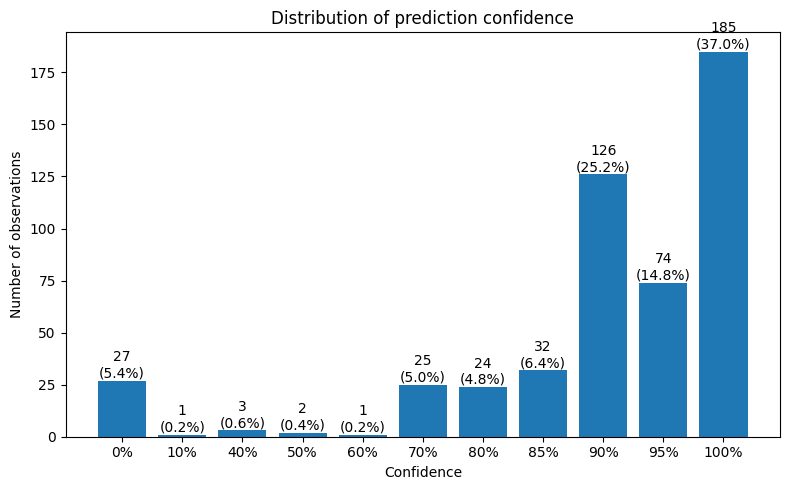

In [91]:
import matplotlib.pyplot as plt

# Antal observationer pr. confidence-værdi
confidence_counts = (
    results["confidence"]
    .value_counts()
    .sort_index()
)

# Andel observationer pr. confidence-værdi
confidence_shares = confidence_counts / confidence_counts.sum()

# Konvertér confidence til procent til x-aksen
confidence_labels = [
    f"{value:.0%}"
    for value in confidence_counts.index
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    confidence_labels,
    confidence_counts.values
)

plt.title("Distribution of prediction confidence")
plt.xlabel("Confidence")
plt.ylabel("Number of observations")

# Skriv både antal og andel over hver søjle
for bar, count, share in zip(
    bars,
    confidence_counts.values,
    confidence_shares.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({share:.1%})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = results

# Hvis din dataframe hedder noget andet, erstattes df nedenfor
# Sikr at koder behandles som tekst
df["true_code"] = df["true_code"].astype(str).str.strip()
df["pred_code"] = df["pred_code"].astype(str).str.strip()

# Identificér matchtyper
exact_match = df["pred_code"] == df["true_code"]

included_match = (
    df.apply(
        lambda row: row["true_code"].startswith(row["pred_code"]),
        axis=1
    )
    & ~exact_match
)

df["match_type"] = np.select(
    [
        exact_match,
        included_match
    ],
    [
        "Exact match",
        "Contained in true code"
    ],
    default="No match"
)

# Beregn antal og andele
match_summary = (
    df["match_type"]
    .value_counts()
    .reindex(
        ["Exact match", "Contained in true code", "No match"],
        fill_value=0
    )
    .rename_axis("match_type")
    .reset_index(name="n")
)

match_summary["share"] = match_summary["n"] / len(df) * 100

print(match_summary)

               match_type    n  share
0             Exact match  235   47.0
1  Contained in true code  147   29.4
2                No match  118   23.6


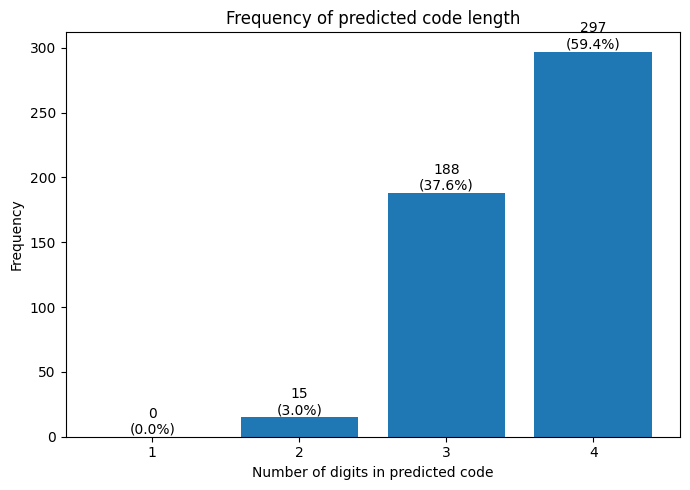

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Behandl pred_code som tekst og fjern punktum
df["pred_code_str"] = df["pred_code"].astype(str).str.strip()

# Beregn antal cifre i den prædikterede kode
df["pred_code_length"] = (
    df["pred_code_str"]
    .str.replace(".", "", regex=False)
    .str.len()
)

# Frequency for 1-, 2-, 3- og 4-cifrede koder
length_frequency = (
    df["pred_code_length"]
    .value_counts()
    .reindex([1, 2, 3, 4], fill_value=0)
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    length_frequency.index.astype(str),
    length_frequency.values
)

plt.title("Frequency of predicted code length")
plt.xlabel("Number of digits in predicted code")
plt.ylabel("Frequency")

total = length_frequency.sum()

for bar, count in zip(bars, length_frequency.values):
    share = count / total
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({share:.1%})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Pipeline evaluation
To understand where the pipeline succeeds or fails, we evaluate each stage separately. Three metrics are useful here.

              ┌─────────────────────────────────────────────────┐
              │             EVALUATION METRICS                  │
              ├──────────────────┬──────────────────────────────┤
              │ Retriever@k      │ Is the correct code among    │
              │ accuracy         │ the k retrieved candidates?  │
              ├──────────────────┼──────────────────────────────┤
              │ LLM accuracy     │ When the retriever succeeded,│
              │ (conditional)    │ does the LLM pick the right  │
              │                  │ code?                        │
              ├──────────────────┼──────────────────────────────┤
              │ Pipeline         │ Is the final predicted code  │
              │ accuracy         │ correct? (end-to-end)        │
              └──────────────────┴─────────────────────────────

These three metrics are related by:

This decomposition helps pinpoint whether errors come from the retriever or the LLM, and guides improvement efforts.

Pipeline accuracy = retriever@k x LLM accuracy (conditional)

Exercise 3: Compute evaluation metrics

Prepare evaluation columns
Before computing any metric, add three boolean columns to results:

- retriever_hit: whether the true NACE code is among the k candidates returned by Qdrant
- pipeline_correct: whether the predicted code matches the true code
- llm_correct_given_retriever: same as pipeline_correct, but set to None when the retriever did not return the true code

In [97]:
# Is the true code among the retriever's candidates?
results["retriever_hit"] = results.apply(
    lambda row: row["true_code"] in row["retrieved_codes"], axis=1
)

# Is the predicted code correct?
results["pipeline_correct"] = results["pred_code"] == results["true_code"]

# Did the LLM pick the right code, given that the retriever found it?
results["llm_correct_given_retriever"] = results.apply(
    lambda row: row["pipeline_correct"] if row["retriever_hit"] else None,
    axis=1
)

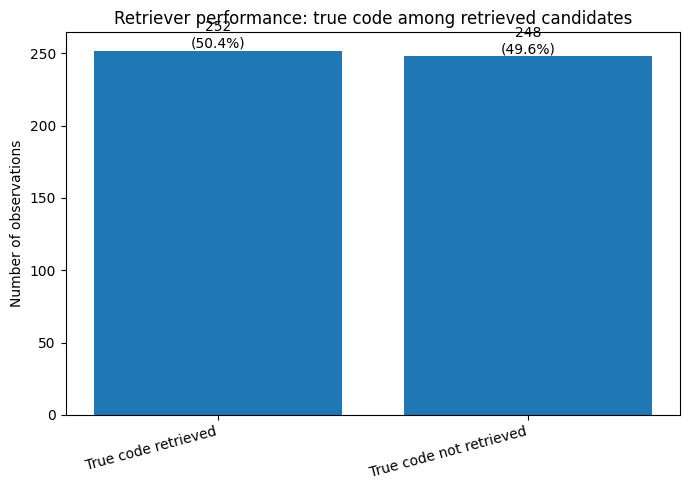

In [98]:
import matplotlib.pyplot as plt

# Antal observationer, hvor true_code findes/ikke findes i retrieved_codes
retriever_summary = (
    results["retriever_hit"]
    .map({
        True: "True code retrieved",
        False: "True code not retrieved"
    })
    .value_counts()
    .reindex(
        ["True code retrieved", "True code not retrieved"],
        fill_value=0
    )
)

# Andele
retriever_shares = retriever_summary / retriever_summary.sum()

# Søjlediagram
plt.figure(figsize=(7, 5))

bars = plt.bar(
    retriever_summary.index,
    retriever_summary.values
)

plt.title("Retriever performance: true code among retrieved candidates")
plt.xlabel("")
plt.ylabel("Number of observations")

# Tilføj antal og andel over søjlerne
for bar, count, share in zip(
    bars,
    retriever_summary.values,
    retriever_shares.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({share:.1%})",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [99]:
pd.crosstab(
    results["pipeline_correct"],
    results["retriever_hit"],
    margins=True
)

retriever_hit,False,True,All
pipeline_correct,,,
False,247,18,265
True,1,234,235
All,248,252,500


Question 1 — Retriever accuracy (Retriever@k)

Retriever@k accuracy measures the proportion of cases where the reference code is present among the k candidates returned by Qdrant. It is the theoretical ceiling of the pipeline: if the retriever misses the correct code, the LLM cannot recover it.

Retriever@k = N_hit / N

where N_hit is the number of activities for which the true code is among the k retrieved candidates, and N is the total number of activities.

Using the retriever_hit column, compute the proportion of rows where the retriever returned the true code. Store the result in a variable called retriever_accuracy.

In [101]:
retriever_accuracy = results["retriever_hit"].mean()
print(f"Retriever@{RETRIEVER_LIMIT} accuracy: {retriever_accuracy:.1%}")
print(f"  → {results['retriever_hit'].sum()} / {len(results)} correctly retrieved")

Retriever@5 accuracy: 50.4%
  → 252 / 500 correctly retrieved


Question 2 — Conditional LLM accuracy

Conditional LLM accuracy measures how often the LLM picks the right code when the retriever already returned it as a candidate. This metric isolates the LLM’s own contribution to the pipeline.

 LLM accuracy = N_correct_hit / N_hit

where N_correct_hit is the number of correct predictions in the subset where the retriever succeeded.

Filter results to keep only the rows where retriever_hit is True, then compute the proportion of pipeline_correct in that subset. Store the result in llm_accuracy.

In [102]:
retriever_success = results[results["retriever_hit"]]
llm_accuracy = retriever_success["pipeline_correct"].mean()

print(f"LLM accuracy (conditional on retriever): {llm_accuracy:.1%}")
print(f"  → {retriever_success['pipeline_correct'].sum()} / {len(retriever_success)} correctly coded by the LLM")

LLM accuracy (conditional on retriever): 92.9%
  → 234 / 252 correctly coded by the LLM


Question 3 — End-to-end pipeline accuracy

End-to-end pipeline accuracy is the proportion of activity labels that are correctly coded, regardless of which component failed.

Pipeline accuracy = Retriever@k x LLM accuracy

Compute the overall accuracy from the pipeline_correct column and store it in pipeline_accuracy. Then verify empirically that the multiplicative relationship with retriever_accuracy and llm_accuracy holds.

In [103]:
pipeline_accuracy = results["pipeline_correct"].mean()

print(f"Pipeline accuracy (end-to-end)          : {pipeline_accuracy:.1%}")
print(f"  → {results['pipeline_correct'].sum()} / {len(results)} correctly coded")
print()
print(f"Cross-check: Retriever@k × LLM = {retriever_accuracy:.3f} × {llm_accuracy:.3f} = {retriever_accuracy * llm_accuracy:.1%}")

Pipeline accuracy (end-to-end)          : 47.0%
  → 235 / 500 correctly coded

Cross-check: Retriever@k × LLM = 0.504 × 0.929 = 46.8%


Question 4 — Summary dashboard and error decomposition

Count how many errors come from the retriever (cases where retriever_hit is False) and how many come from the LLM (cases where retriever_hit is True but pipeline_correct is False). Then produce a summary table of all metrics.

In [104]:
n_total          = len(results)
n_retriever_miss = (~results["retriever_hit"]).sum()
n_llm_miss       = (results["retriever_hit"] & ~results["pipeline_correct"]).sum()
n_correct        = results["pipeline_correct"].sum()

print(
    "\n".join(
        [
            "=" * 52,
            "      DASHBOARD — RAG PIPELINE NACE 2.1",
            "=" * 52,
            f"  Activities processed        : {n_total:>6}",
            f"  Correctly coded             : {n_correct:>6}  ({pipeline_accuracy:.1%})",
            "",
            f"  Retriever@{RETRIEVER_LIMIT} accuracy        : {retriever_accuracy:>6.1%}",
            f"  LLM accuracy (conditional)  : {llm_accuracy:>6.1%}",
            f"  Pipeline accuracy           : {pipeline_accuracy:>6.1%}",
            "",
            f"  Retriever errors            : {n_retriever_miss:>6}  ({n_retriever_miss / n_total:.1%})",
            f"  LLM errors                  : {n_llm_miss:>6}  ({n_llm_miss / n_total:.1%})",
            "=" * 52,
        ]
    )
)

      DASHBOARD — RAG PIPELINE NACE 2.1
  Activities processed        :    500
  Correctly coded             :    235  (47.0%)

  Retriever@5 accuracy        :  50.4%
  LLM accuracy (conditional)  :  92.9%
  Pipeline accuracy           :  47.0%

  Retriever errors            :    248  (49.6%)
  LLM errors                  :     18  (3.6%)


Note: How to interpret the error decomposition:

If retriever errors dominate → improve the embedding model, increase k, or enrich NACE descriptions in the vector store.
If LLM errors dominate → refine the prompt, switch to a more capable generative model, or lower the temperature further.

Not all errors are equal. A wrong prediction can mean very different things. Some errors are completely off, predicting a manufacturing code for a services activity. Others are near-misses: the predicted code is a parent (e.g. 47 instead of 47.11) or a sibling at the same level of the hierarchy. Near-misses may be acceptable in practice, depending on how the coded data will be used. A hierarchical accuracy metric (counting a prediction as correct if it matches up to a certain depth) would capture this nuance.

Important: 
On the optimism of these results. The evaluation dataset is synthetic: activity labels were generated by an AI system at low temperature, producing clean and unambiguous descriptions that are easier to classify than real-world data. Actual labels are often shorter, noisier, or ambiguous. The accuracy figures obtained here are therefore optimistic and should not be taken as representative of production performance.

Question 5 — Confidence score analysis

The LLM returns a confidence score with each prediction. In production, this score can serve as a quality signal to filter out unreliable predictions — at the cost of reduced coverage (fewer activities are automatically coded, the rest going to manual review).

Produce two complementary plots to investigate this trade-off:

a) A boxplot of the confidence score, split by prediction correctness (correct vs. incorrect). Does the LLM assign higher confidence to predictions that turn out to be correct?
b) A precision–coverage curve as a function of the confidence threshold. For each threshold t ∈ {0.1, 0.2, ..., 0.9}, compute:
- precision: accuracy on the subset of predictions with confidence ≥ t
- coverage: share of the dataset that survives the threshold
What confidence threshold would you choose if you wanted at least 95% precision? What coverage do you get?

In [ ]:
pip install plotnine

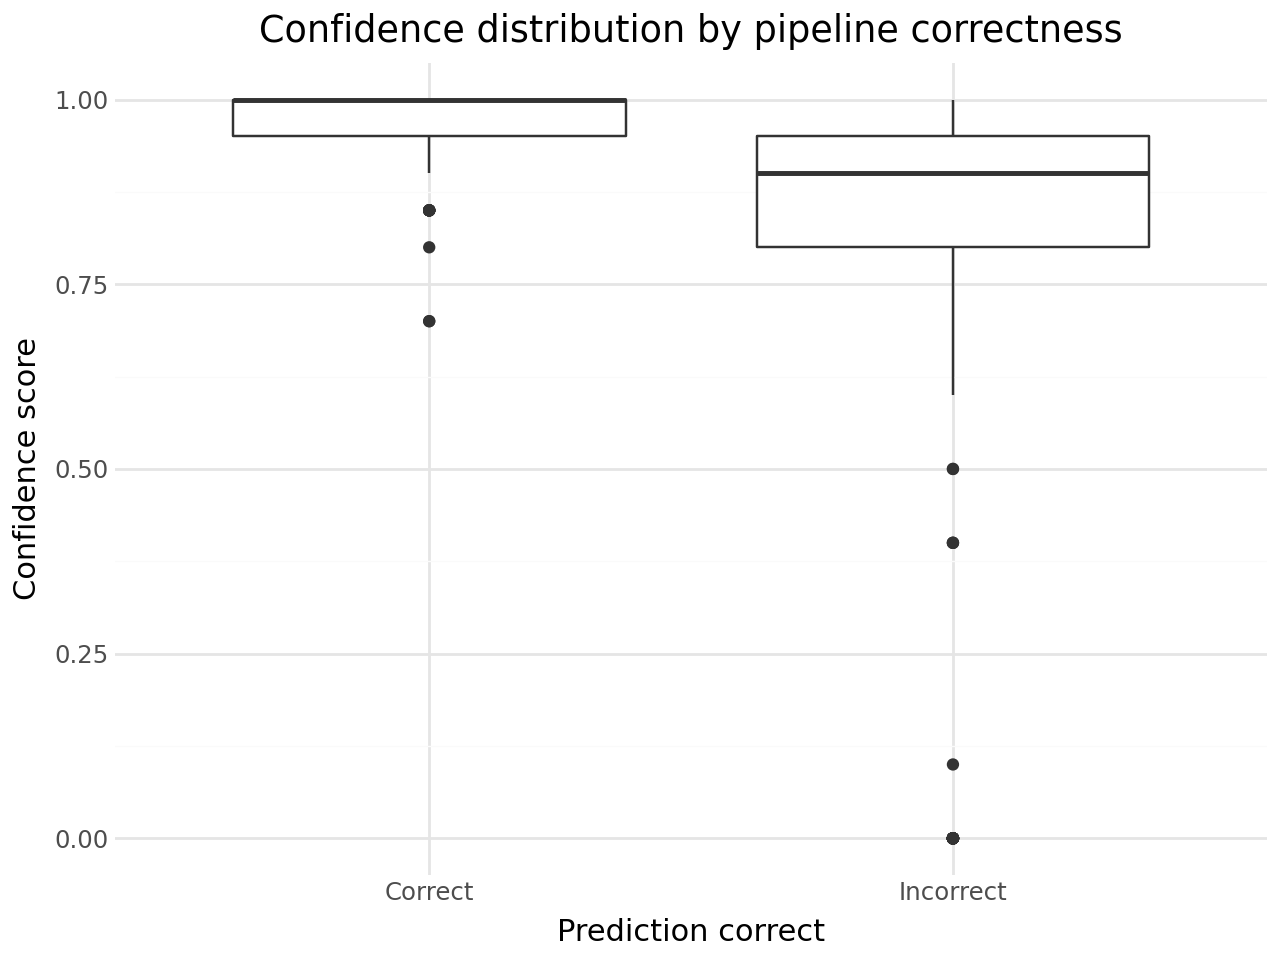

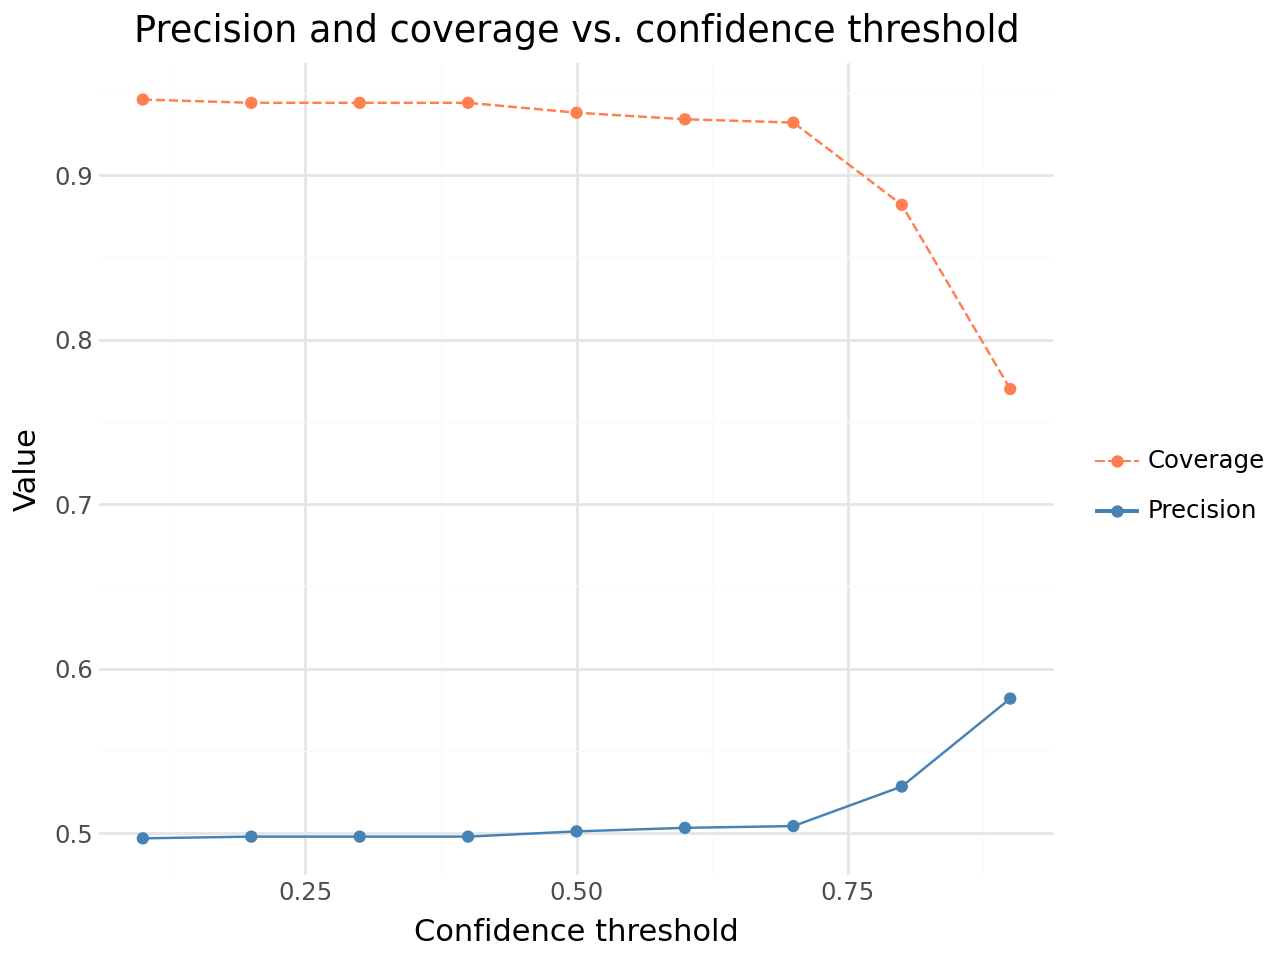

In [107]:
from plotnine import (
    ggplot, aes,
    geom_boxplot, geom_line, geom_point,
    scale_color_manual, scale_linetype_manual,
    labs, theme_minimal,
)


# --- Left: confidence distribution by correctness ---
results_plot = results.assign(
    correctness=results["pipeline_correct"].map({False: "Incorrect", True: "Correct"})
)

p1 = (
    ggplot(results_plot, aes(x="correctness", y="confidence"))
    + geom_boxplot()
    + labs(
        title="Confidence distribution by pipeline correctness",
        x="Prediction correct",
        y="Confidence score",
    )
    + theme_minimal()
)

# --- Right: precision and coverage vs confidence threshold ---
thresholds = [i / 10 for i in range(1, 10)]
rows = []
for t in thresholds:
    subset = results[results["confidence"] >= t]
    if len(subset) > 0:
        rows += [
            {"threshold": t, "metric": "Precision", "value": subset["pipeline_correct"].mean()},
            {"threshold": t, "metric": "Coverage",  "value": len(subset) / len(results)},
        ]

df_thresh = pd.DataFrame(rows)

p2 = (
    ggplot(df_thresh, aes(x="threshold", y="value", color="metric", linetype="metric"))
    + geom_line()
    + geom_point()
    + scale_color_manual(values={"Precision": "steelblue", "Coverage": "coral"})
    + scale_linetype_manual(values={"Precision": "solid", "Coverage": "dashed"})
    + labs(
        title="Precision and coverage vs. confidence threshold",
        x="Confidence threshold",
        y="Value",
        color="",
        linetype="",
    )
    + theme_minimal()
)

from IPython.display import display
display(p1)
display(p2)

Note: Precision / coverage trade-off: raising the confidence threshold increases precision (the retained predictions are more likely to be correct) but reduces coverage (fewer labels are automatically coded, the rest requiring manual review). Choosing the right threshold depends on the operational constraints of your use case.

What you learned — and how to go further

Key concepts of the RAG approach

Across the two RAG tutorials you built a complete pipeline from raw text to a coded NACE label:

- Vector database (tutorial 1): NACE definitions were cleaned, embedded with a dense model, and stored in Qdrant as PointStruct objects with deterministic UUIDs. The choice of embedding model and the richness of the stored text (includes, excludes) directly shape retrieval quality.
- Semantic retrieval: at inference time, the activity label is embedded with the same model and the k nearest neighbours are fetched from Qdrant. Retriever@k is the hard ceiling of the pipeline — if the correct code is not retrieved, the LLM cannot recover it.
- Structured generation: the retrieved candidates are injected into a prompt and the LLM is asked to pick one, returning a typed NaceClassificationResult object via beta.chat.completions.parse(). Pydantic constraints catch malformed responses at parse time.
- Decomposed evaluation: pipeline accuracy factors as Retriever@k × LLM accuracy (conditional). This decomposition pinpoints where errors occur and guides improvements.
- Confidence-based triage: the LLM confidence score enables a precision/coverage trade-off — high-confidence predictions are sent to automatic coding, low-confidence ones to human review.

What to try next

Improve the retriever

- Larger or domain-adapted embedding model: a model fine-tuned on economic activity descriptions would produce better semantic clusters than a general-purpose one.
- Hybrid search: combine dense (embedding) and sparse (BM25 keyword) search. Qdrant supports this natively. Useful when the activity label contains exact NACE terminology.
- Increase k and rerank: retrieve more candidates (e.g. k=10) and add a lightweight cross-encoder reranker to re-score them before passing the top-5 to the LLM. Rerankers are better at fine-grained relevance but too slow to run over the full collection.

Improve the generator

-Few-shot examples in the prompt: add 2–3 labelled examples (activity → code) to the user prompt. This helps the LLM calibrate on the expected granularity of the nomenclature.
-Chain-of-thought: ask the LLM to reason step-by-step before outputting the JSON. Adds latency but can improve accuracy on ambiguous labels.
- More capable model: swap GEN_MODEL_NAME for a larger or instruction-tuned model — generation errors are usually the cheaper component to improve.

Better evaluation

- Hierarchical accuracy: count a prediction as partially correct if it matches the true code at the section or division level (e.g. 47 matches 47.11). This is more informative than strict exact-match for a 4-level hierarchy.
- Larger evaluation set: SAMPLE_SIZE = 100 gives noisy estimates. Run on the full dataset or use bootstrap confidence intervals.
- Error analysis by sector: accuracy may vary widely across NACE sections. Identifying weak sectors guides targeted improvements.

Production considerations

- Caching embeddings: if the same activity labels recur (e.g. standard job titles), cache their embeddings to avoid redundant API calls.
- Async batching: parallelise the embedding + generation calls with asyncio to reduce wall-clock time on large batches.
- Human-in-the-loop: route low-confidence predictions (confidence < t) to a review queue rather than discarding them — combine automatic coding with human validation to maximise both precision and coverage.